<a href="https://colab.research.google.com/github/abhishekanand04/ML-Supervised-Algorithms/blob/supervised-alogorithm/kNN_Under_Over.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# For scaling data
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn import metrics

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

X = df.iloc[:, 0:2]
y = df.loc[:, 'target'].values


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0,
                                                    test_size = .2)
from sklearn.neighbors import KNeighborsClassifier

(61600, 2)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


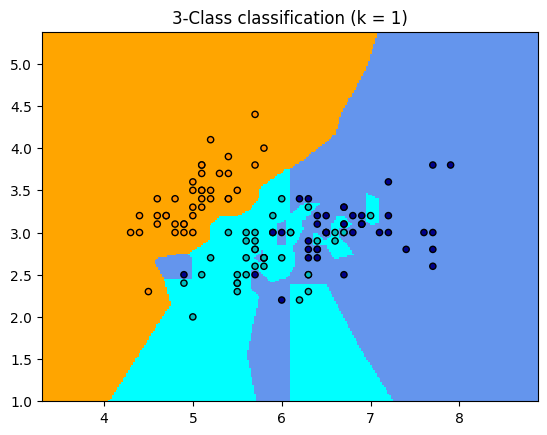

(61600, 2)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


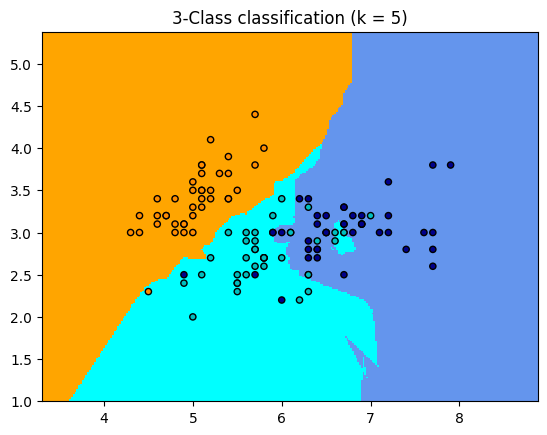

(61600, 2)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


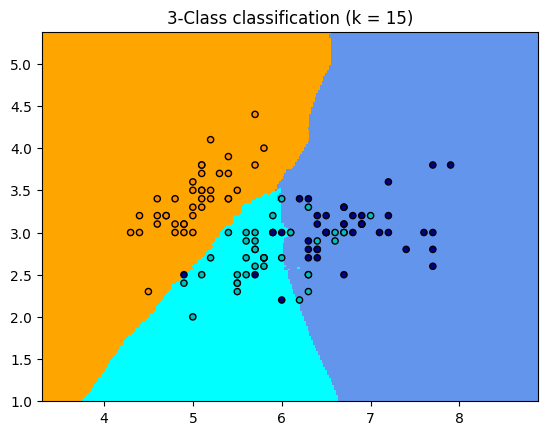

In [ ]:

#Neighbor = 5
for Neighbor in [1,5,15]:
    knn = KNeighborsClassifier(n_neighbors=Neighbor)
    knn.fit(X_train, y_train)

    cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
    cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])
    h = .02  # step size in the mesh


    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X_train.loc[:, 'sepal length (cm)'].values.min() - 1, X_train.loc[:, 'sepal length (cm)'].values.max() + 1
    y_min, y_max = X_train.loc[:, 'sepal width (cm)'].values.min() - 1, X_train.loc[:, 'sepal width (cm)'].values.max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    print(np.c_[xx.ravel(), yy.ravel()].shape)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='nearest')

    # Plot also the training points
    plt.scatter(X_train.loc[:, 'sepal length (cm)'].values,
                X_train.loc[:, 'sepal width (cm)'].values,
                c=y_train,
                cmap=cmap_bold,
                edgecolor='k',
                s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f"3-Class classification (k = {Neighbor})")
    plt.show()